[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dcintlab/WignerCamp2026/blob/main/AnomalyDetectionCalculations/generate_data_peaks_baseline.ipynb)

In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My\ Drive/WignerCamp2026/AnomalyDetection
    # altx and artificial-dataset are not on PyPI yet, install them from GitHub
    # (see the README for the corresponding `git clone` instructions).
    !pip install optuna --quiet
    !pip install "git+https://github.com/intensivedatacomp/artificial-dataset.git" --quiet
    !pip install "git+https://github.com/halmosb/altx.git" --quiet
except Exception:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

# Anomaly detection: a `find_peaks` baseline vs. an `altx` pipeline

This notebook builds an anomaly-detection benchmark on a synthetic time series and
compares two ways of locating the anomalies (positive spikes):

1. **Baseline** — run [`OptimizedFindPeaks`](optimized_find_peaks.py) directly on the
   raw signal. The `scipy.signal.find_peaks` parameters are tuned with Optuna to
   maximise the **F1 score** against the known spike locations.
2. **`altx` pipeline** — first transform the signal with the *Adaptive Law-based
   Transformation* ([`altx`](https://github.com/halmosb/altx)), which turns the series
   into an *anomaly score* (large where the normal dynamics are violated), then run the
   same `OptimizedFindPeaks` on the transformed signal.

The dataset is split **contiguously in time** into **train / validation / test** —
this split is built into `make_anomaly_dataset`. We use the splits as follows:

| Stage | train | validation | test |
|---|---|---|---|
| **Baseline** | tune `find_peaks` | tune `find_peaks` | **final F1** |
| **`altx`** | learn the laws | tune `find_peaks` | **final F1** |

In [2]:
import math

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from artificial_dataset import make_anomaly_dataset, SpikeParams
from altx import ALT as Altx

from optimized_find_peaks import (
    OptimizedFindPeaks,
    _as_index_mask,
    _make_metric_scorer,
)

SEED = 5          # reproducibility
TOLERANCE = 5     # a detected peak counts as correct if within +/- 5 samples of a true spike

## 1. Generate and split the dataset

`make_anomaly_dataset` returns a single multivariate series. With `split=(...)` it
hands back an `AnomalySplits` object whose `.train`, `.val` and `.test` are contiguous
time segments. Each segment exposes:

- `y` — the signal, shape `(channels, T)`,
- `labels` — per-timestep mask (`1` inside a spike),
- `t` — the time grid,
- `peak_indices` — the ground-truth spike centres (already re-based to local indices).

We use a single channel and treat `peak_indices` as the ground truth for `find_peaks`.

In [3]:
splits = make_anomaly_dataset(
    series_length=3000,
    noise_std=0.7,
    x_range=(0.0, 30.0 * math.pi),
    spike_params=SpikeParams(
        amplitude_range=(2.0, 5.0),   # spikes rise well above the baseline...
        width_range=(1, 3),
        count_range=(30, 40),         # ...and there are plenty, so every split has some
        margin=20,
    ),
    split=(0.5, 0.25, 0.25),
    random_state=SEED,
)

train, val, test = splits.train, splits.val, splits.test

for name, ds in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}: y={tuple(ds.y.shape)}, "
          f"spikes={ds.peak_indices.numel()}")

train: y=(1, 1500), spikes=12
val  : y=(1, 750), spikes=8
test : y=(1, 750), spikes=13


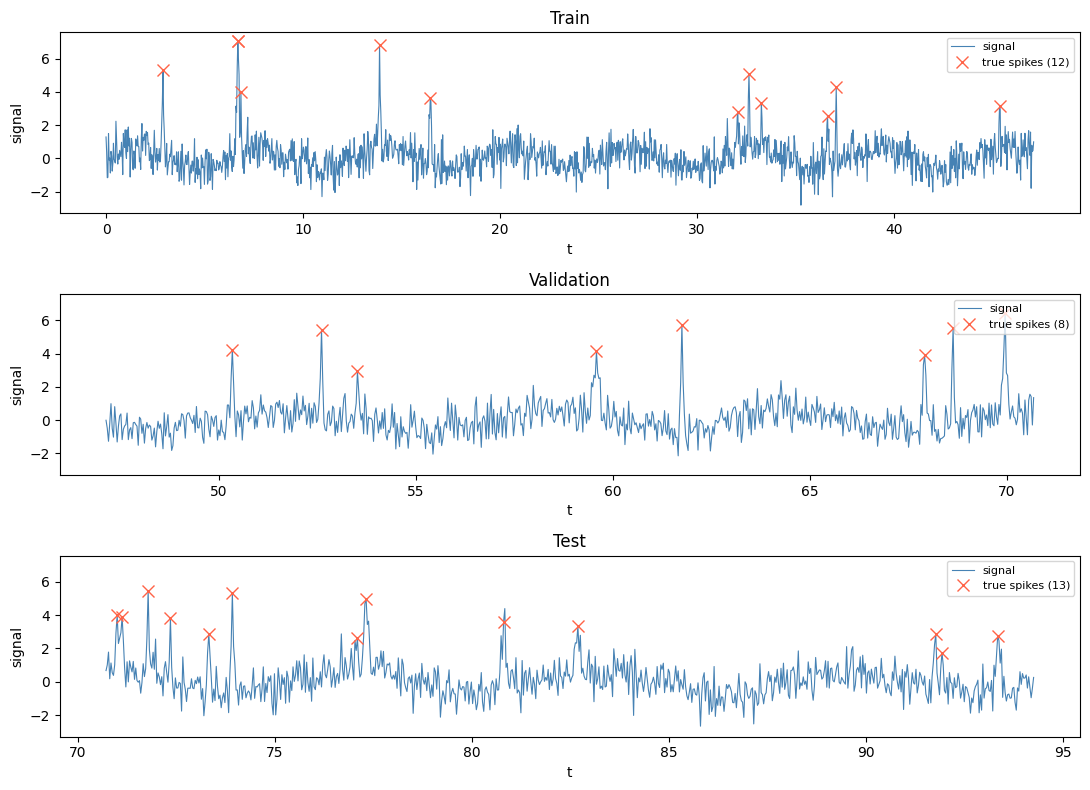

In [4]:
def plot_series(ds, ax, title):
    sig = ds.y[0].numpy()
    t = ds.t.numpy()
    pk = ds.peak_indices.numpy()
    ax.plot(t, sig, lw=0.8, color="steelblue", label="signal")
    ax.plot(t[pk], sig[pk], "x", ms=9, color="tomato",
            label=f"true spikes ({pk.size})")
    ax.set_title(title)
    ax.set_xlabel("t")
    ax.set_ylabel("signal")
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharey=True)
plot_series(train, axes[0], "Train")
plot_series(val, axes[1], "Validation")
plot_series(test, axes[2], "Test")
plt.tight_layout()
plt.show()

## 2. Baseline — `OptimizedFindPeaks` on the raw signal

`OptimizedFindPeaks` runs an Optuna search over the `find_peaks` parameters (`height`,
`prominence`, `distance`, ...) to maximise the F1 score between the detected peaks and
the true spike centres, using a tolerance when matching.

For the baseline we tune on the **train + validation** sets (concatenated into one
signal) and report the **final F1 on the untouched test set**.

In [5]:
def channel0(ds):
    '''Return the first channel of a split as a 1-D numpy array.'''
    return ds.y[0].numpy()


def peak_f1(signal, true_peaks, optimizer, tolerance=TOLERANCE):
    '''F1 of an optimizer's detections on `signal`, matched to `true_peaks`.

    Uses the exact same peak-matching metric that `OptimizedFindPeaks`
    optimizes, so the score is comparable to `optimizer.best_score_`.
    '''
    signal = np.asarray(signal, dtype=float).ravel()
    true_mask = _as_index_mask(np.asarray(true_peaks), signal.shape[0])
    pred_peaks, _ = optimizer.predict(signal)
    scorer = _make_metric_scorer("f1", tolerance)
    return scorer(true_mask, pred_peaks, signal.shape[0]), pred_peaks

In [6]:
# Concatenate train + val into one tuning signal; offset the val spike indices.
trainval_signal = np.concatenate([channel0(train), channel0(val)])
trainval_peaks = np.concatenate(
    [train.peak_indices.numpy(), val.peak_indices.numpy() + train.y.shape[1]]
)

baseline_opt = OptimizedFindPeaks(
    scorer="f1",
    n_trials=200,
    tolerance=TOLERANCE,
    seed=SEED,
)
baseline_opt.fit(trainval_signal, trainval_peaks)

baseline_test_f1, baseline_test_peaks = peak_f1(
    channel0(test), test.peak_indices.numpy(), baseline_opt
)

print(f"Best params (train+val) : {baseline_opt.best_params_}")
print(f"F1 on train+val         : {baseline_opt.best_score_:.3f}")
print(f"F1 on TEST              : {baseline_test_f1:.3f}")
print(f"Detected {baseline_test_peaks.size} peaks vs "
      f"{test.peak_indices.numel()} true spikes on the test set.")

Best params (train+val) : {'height': 2.5390570752399912, 'prominence': 0.23920616170875333, 'distance': 1}
F1 on train+val         : 0.974
F1 on TEST              : 0.828
Detected 16 peaks vs 13 true spikes on the test set.


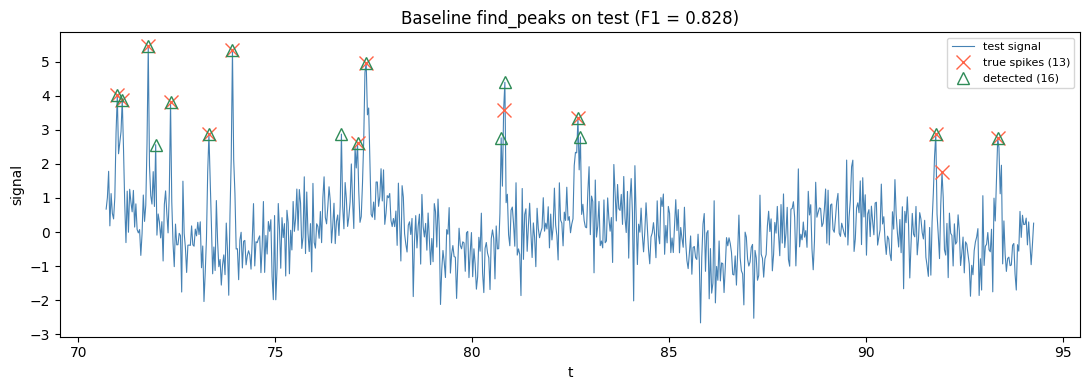

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
sig = channel0(test)
t = test.t.numpy()
pk = test.peak_indices.numpy()
ax.plot(t, sig, lw=0.8, color="steelblue", label="test signal")
ax.plot(t[pk], sig[pk], "x", ms=10, color="tomato",
        label=f"true spikes ({pk.size})")
ax.plot(t[baseline_test_peaks], sig[baseline_test_peaks], "^", ms=9,
        color="seagreen", mfc="none",
        label=f"detected ({baseline_test_peaks.size})")
ax.set_title(f"Baseline find_peaks on test (F1 = {baseline_test_f1:.3f})")
ax.set_xlabel("t")
ax.set_ylabel("signal")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Transform the data with `altx`

`altx` learns the **linear laws** that the *normal* part of the series obeys (via
time-delay embedding + eigen-decomposition). Multiplying a new window by these laws
gives a residual that is ~0 where the data follows the normal dynamics and **large at
anomalies**. We turn that residual into a 1-D **anomaly score** that `find_peaks` can
then work on.

**Training data.** `altx` should learn from *normal* data only, so we cut the **train**
series at its anomaly timesteps into spike-free segments and feed those as separate
(class-0) instances of possibly different lengths (`train_length`).

In [8]:
# Cut the train series into spike-free segments at the labelled anomaly timesteps.
train_set = train.y.unsqueeze(0)               # (1, channels, T)
anomaly_t = (train.labels == 1).nonzero(as_tuple=True)[0].tolist()

RLK = (None, 3, 1)
N = train_set.shape[-1]
boundaries = [-1] + anomaly_t + [N]

MIN_SEG = 2*RLK[1]   # a segment must be at least one embedding window long
segments = []
for lo, hi in zip(boundaries[:-1], boundaries[1:]):
    start, end = lo + 1, hi
    if end - start >= MIN_SEG:
        segments.append(train_set[..., start:end])

# Pad to a common length and stack into (instances, channels, max_len).
train_lengths = torch.tensor([seg.shape[-1] for seg in segments])
max_len = int(train_lengths.max())
train_segments = torch.cat(
    [F.pad(seg, (0, max_len - seg.shape[-1])) for seg in segments], dim=0
)
train_classes = torch.zeros(train_segments.shape[0])

print(f"{len(segments)} normal segments, lengths "
      f"{train_lengths.min().item()}..{train_lengths.max().item()}")

11 normal segments, lengths 9..491


In [9]:
# (r, l, k): r=None lets altx pick r = 2*l - 1 (here 9); the transform shortens
# the series by l - 1 samples at the end.
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Altx(
    train_set=train_segments,
    train_classes=train_classes,
    train_length=train_lengths,
    R=RLK[0], L=RLK[1], K=RLK[2],
    device=device,
)
model.train()
model.print_number_of_laws()

L = model.RLK[0][1]   # embedding dimension actually used


def altx_score(ds):
    '''Transform a split into a 1-D anomaly score (+ aligned t and true peaks).

    The score is the mean squared projection of each window onto the learned
    laws (no normalisation, so the spike amplitude is preserved).
    '''
    transformed = model.multiply_only(z=ds.y, rlk=model.RLK[0], normalize_data=False)
    score = (transformed[:, :, 0] ** 2).mean(dim=1).cpu().numpy()
    t = ds.t.numpy()[: score.shape[0]]
    pk = ds.peak_indices.numpy()
    pk = pk[pk < score.shape[0]]      # keep spikes that survive the end trim
    return score, t, pk


val_score, val_t, val_peaks = altx_score(val)
test_score, test_t, test_peaks = altx_score(test)
print(f"transformed val: {val_score.shape}, test: {test_score.shape}")

Number of laws for r = 5, l = 3, k = 1:
(tensor([0.]), tensor([1403]))
transformed val: (748,), test: (748,)


## 4. `OptimizedFindPeaks` on the `altx` anomaly score

Now we tune `find_peaks` on the **transformed validation** score and report the
**final F1 on the transformed test** score — `altx` saw only the train set, so the
test set stays a genuine hold-out.

In [10]:
altx_opt = OptimizedFindPeaks(
    scorer="f1",
    n_trials=200,
    tolerance=TOLERANCE,
    seed=SEED,
)
altx_opt.fit(val_score, val_peaks)

altx_test_f1, altx_test_peaks = peak_f1(test_score, test_peaks, altx_opt)

print(f"Best params (val)  : {altx_opt.best_params_}")
print(f"F1 on validation   : {altx_opt.best_score_:.3f}")
print(f"F1 on TEST         : {altx_test_f1:.3f}")
print(f"Detected {altx_test_peaks.size} peaks vs "
      f"{test_peaks.size} true spikes on the test set.")

Best params (val)  : {'height': 3.382698219928149, 'prominence': 0.0929432965506189, 'distance': 6}
F1 on validation   : 1.000
F1 on TEST         : 0.917
Detected 11 peaks vs 13 true spikes on the test set.


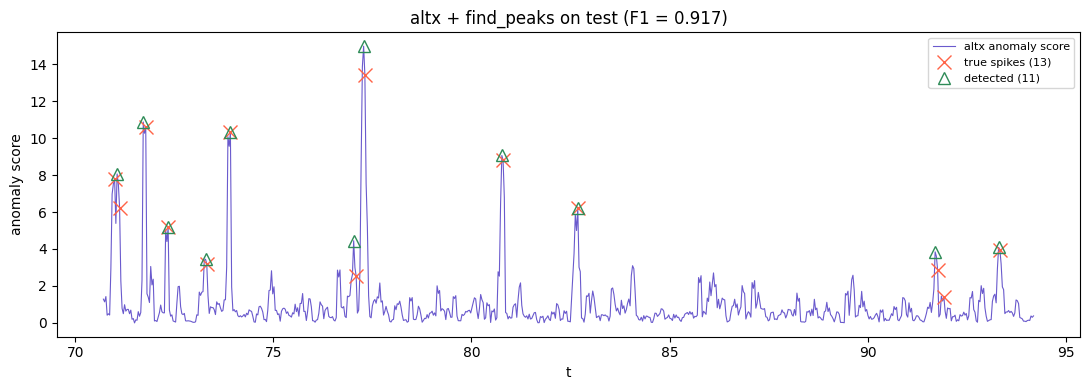

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test_t, test_score, lw=0.8, color="slateblue", label="altx anomaly score")
ax.plot(test_t[test_peaks], test_score[test_peaks], "x", ms=10, color="tomato",
        label=f"true spikes ({test_peaks.size})")
ax.plot(test_t[altx_test_peaks], test_score[altx_test_peaks], "^", ms=9,
        color="seagreen", mfc="none",
        label=f"detected ({altx_test_peaks.size})")
ax.set_title(f"altx + find_peaks on test (F1 = {altx_test_f1:.3f})")
ax.set_xlabel("t")
ax.set_ylabel("anomaly score")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Summary

In [12]:
print("Final test F1 scores")
print("--------------------")
print(f"Baseline (raw find_peaks) : {baseline_test_f1:.3f}")
print(f"altx + find_peaks         : {altx_test_f1:.3f}")

Final test F1 scores
--------------------
Baseline (raw find_peaks) : 0.828
altx + find_peaks         : 0.917
